In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.optim as optim
import pickle
import torch.nn as nn
from nice.algorithms.connectivity_AT import *
from IPython.display import clear_output
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter1d

from scipy.stats import pearsonr


c:\Users\joshu\nice\.venv\Lib\site-packages\mne\externals\tempita\__init__.py:35: DeprecationWarning: 'cgi' is deprecated and slated for removal in Python 3.13
  import cgi


In [ ]:
file_numbers = [1,2, 4, 8]

structure = {f'dataset_{file_number}': {
    'left_attleft': [],
    'right_attleft': [],
    'left_attright': [],
    'right_attright': []
} for file_number in file_numbers}

def smooth_with_gaussian(data, sigma=2):
    return gaussian_filter1d(data, sigma=sigma, axis=1)  # Gaussian filter along the time axis

def preprocess(data):   # This will receive (trials, time, neurons). Therefore mean across trials. 
    data_z = np.zeros_like(data)
    mean = np.mean(data, axis = 0)
    std = np.std(data, axis = 0)
   
    std[std == 0] = 1  # Avoid division by zero by setting std to 1 where it is 0
    data_z = (data - mean) / std
    return data_z

def get_data(file_number):
    file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{file_number}_attention_test'
    data = pickle.load(open(file_path, 'rb'))

    label_left = data['label_left'][0]
    label_right = data['label_right'][0]  #for class of input
    attend_01 = data['attend'][0]
    omitted = data['omit'][0]
    relevant = np.where(omitted == 0)[0]
    label_predict = data['label_predict'][0]

    left = data['SP'][0][0][relevant, 100:350, :]
    right = data['SP'][0][1][relevant, 100:350, :]
    att = data['SP'][0][2][relevant, 100:350, :]


    num_trials, num_samples, num_neurons = left.shape
    num_neurons_attention = 80

    for j in range(0, num_trials):
        for i in range(0, num_neurons):
            count_left = np.count_nonzero(left[j, :, i] == 1)
            if count_left > 0:
                left[j, :, i] /= count_left
            count_right = np.count_nonzero(right[j, :, i] == 1)
            if count_right > 0:
                right[j, :, i] /= count_right



    left = preprocess(left)
    right = preprocess(right)
    
    
   
    # Can now split into left and right attentional modality
    left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right) & (label_left == label_predict))[0]  # Indices of agg where left
    _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
    right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right) & (label_right == label_predict))[0]
    _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

    # Splitting left and right
    left_attleft = smooth_with_gaussian(left[left_indices], sigma = 2)  # Axis 1 will smooth all of these across time
    right_attleft = smooth_with_gaussian(right[left_indices], sigma = 2)
    att_attleft = att[left_indices]

    left_attright = smooth_with_gaussian(left[right_indices], sigma = 2)
    right_attright = smooth_with_gaussian(right[right_indices], sigma = 2)
    att_attright = att[right_indices]

    return left_attleft, left_attright, right_attleft, right_attright, att_attleft, att_attright
##e.g. dataset 1 gives left_attleft of shape (469 trials, 500 time points, 160 spikes)


def collect_data(file_numbers):
    l_al, l_ar, r_al, r_ar, a_al, a_ar = [], [], [], [], [], []
    for file_number in file_numbers:
        left_attleft, left_attright, right_attleft, right_attright, att_attleft, att_attright = get_data(file_number)
        l_al.append(left_attleft)
        l_ar.append(left_attright)
        r_al.append(right_attleft)
        r_ar.append(right_attright)
        a_al.append(att_attleft)
        a_ar.append(att_attright)
       
    return l_al, l_ar, r_al, r_ar, a_al, a_ar
   

In [ ]:
def smooth_data(data, sigma=1):
    return gaussian_filter1d(data, sigma=sigma, axis=1)  #Gaussian filter along the time axis

def normalize_inputs(x_train, x_test, x_val):   #note that this will take the mean and stc based on the training data only
 
    if np.isnan(x_train).any():
        raise ValueError("Data contains NaN values after normalization.")

    return (
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(x_test, dtype=torch.float32),
        torch.tensor(x_val, dtype=torch.float32)
    )


def normalize_targets(y_train, y_test, y_val):
    #standard scaler
    mean = np.mean(y_train, axis=0, keepdims=True)
    std = np.std(y_train, axis=0, keepdims=True)
    std[std == 0] = 1  # avoid division by zero
    y_train = (y_train - mean) / std
    y_test = (y_test - mean) / std
    y_val = (y_val - mean) / std
    

    print('shape of target', y_train.shape)
    return (
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
    )


In [ ]:
def prep_data(x_list, y_list, batch_size=16, shuffle=True):
    #concatenating all of the datasets
    x_raw = np.concatenate(x_list, axis=0)   # (N, T, neurons)
    y_raw = np.concatenate(y_list, axis=0)   # (N, T, 1) or (N, T)
    print('shape of inputs:',  x_raw.shape)
    print('shape of outputs:', y_raw.shape)

    #finding the output counts
    y_counts = np.sum(y_raw, axis=1) 
    print('number of firings:', y_counts.shape)

    #ttv split
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        x_raw, y_counts, test_size=0.2, random_state=42, shuffle=shuffle
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=42, shuffle=shuffle
    )

    #then norm based on training data
    X_tr, X_te, X_val = normalize_inputs(X_tr, X_te, X_val)
    y_tr, y_te, y_val = normalize_targets(y_tr, y_te, y_val)

    #wrap as tensors
    def make_ds(X, y):
        #x might already be a torch.Tensor (from normalize_inputs)
        if isinstance(X, np.ndarray):
            X = torch.from_numpy(X).float()
        else:
            X = X.float()
        if isinstance(y, np.ndarray):
            y = torch.from_numpy(y).float()
        else:
            y = y.float()
            
        return TensorDataset(X, y)

    train_ds = make_ds(X_tr, y_tr)
    val_ds   = make_ds(X_val, y_val)
    test_ds  = make_ds(X_te,  y_te)

    #build dataloaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, drop_last=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)

    return train_loader, val_loader, test_loader


In [ ]:
import torch.nn.functional as F

class TemporalAttentionPool(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # project each hidden state to a scalar score
        self.score = nn.Linear(hidden_dim, 1)

    def forward(self, h):  
        # h: (B, T, D)
        # 1) compute un‑normalized scores for each t
        alpha = self.score(h).squeeze(-1)       # → (B, T)
        # 2) normalize into attention weights
        alpha = F.softmax(alpha, dim=1)             # → (B, T)
        # 3) weighted sum of hidden states
        c = torch.einsum('bt, btd -> bd', alpha, h)  
        return c                             # → (B, D)


class SpikingAttentionLSTM(nn.Module):
    def __init__(
        self,
        input_dim = 160, 
        hidden_dim = 128,
        output_dim = 80, 
        num_layers = 2, 
        dropout = 0.3,
        pool: str = 'last',
    ):
        super().__init__()
        self.pool = pool
        self.lstm = nn.LSTM(
            input_size = input_dim,
            hidden_size = hidden_dim, 
            batch_first = True,
            num_layers = num_layers,
            dropout = dropout if num_layers > 1 else 0.0,  #dropout only applies if num_layers > 1

        )
        if self.pool == 'att':
            self.attention = TemporalAttentionPool(hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)  #dropout layer

    def forward(self, x):
        out_seq, (h_n, _) = self.lstm(x)
        if self.pool == 'mean':
            # mean over *all* time‑steps
            feat = out_seq.mean(dim=1)         # (batch, hidden_dim)
        elif self.pool == 'att':
            # attention pooling over time
            feat = self.attention(out_seq)
        else:
            # default: last hidden state of the top LSTM layer
            feat = h_n[-1]                     # (batch, hidden_dim)
        
        feat = self.dropout(feat)
        return self.fc(feat)                  # (batch, output_dim)
    
class SimpleAvgMLP(nn.Module):
    def __init__(self, input_dim, output_dim=250, hidden_dims=[128, 64, 32], dropout=0.3):
        super().__init__()
        
        # Create a list to hold all layers
        layers = []
        
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dims[0]))
        #layers.append(nn.LeakyReLU())
        layers.append(nn.Dropout(dropout))
        
        # Hidden layers
        for i in range(len(hidden_dims)-1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
            layers.append(nn.LeakyReLU())
            layers.append(nn.Dropout(dropout))
        
        # Create sequential model for hidden layers
        self.hidden_layers = nn.Sequential(*layers)
        
        # Output layer
        self.output_layer = nn.Linear(hidden_dims[-1], output_dim)
        
    def forward(self, x):
        # x: [batch, time, neurons]
        # collapse time by mean:
        pooled = x.mean(dim=1)         # [batch, neurons]
        h = self.hidden_layers(pooled)  # Apply all hidden layers
        out = self.output_layer(h)      # [batch, output_dim]
        return out  # Return None for attention weights to match LSTM interface

    

In [ ]:
def train(model, train_loader, val_loader,
           criterion, epochs=1000, clip_value = 1.0, 
           lr = 1e-3, wd = 1e-5, patience = 20):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5, verbose=True
    )
    loss_history = []
    validation_loss_history = []

    best_val_loss = float('inf')
    best_model_state = None
    epochs_since_improvement = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)  #gradient clipping
            optimizer.step()
            epoch_loss += loss.item()

        loss_history.append(epoch_loss / len(train_loader))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
           for xb_val, yb_val in val_loader:
                val_loss += criterion(model(xb_val), yb_val).item()
        val_loss_item = val_loss / len(val_loader)
        validation_loss_history.append(val_loss_item)

        scheduler.step(val_loss_item)  # Reduce learning rate if validation loss doesn't improve

        #early stopping
        if val_loss_item < best_val_loss:
            best_val_loss = val_loss_item
            best_model_state = model.state_dict()
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        if epochs_since_improvement >= patience:
            print(f"Early stopping at epoch {epoch} with validation loss: {best_val_loss:.4f}")
            break

        if epoch % 1 == 0:
            clear_output(wait=True)  #clears the Jupyter output cell
            plt.figure(figsize=(10, 7))
            plt.plot(loss_history, label = 'Training Loss')
            plt.plot(validation_loss_history, label = 'Validation Loss')
            plt.legend()
            plt.xlim(0, epochs)
            #plt.ylim(0.2, 0.8)
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.title('Losses')
            plt.grid(True)
            plt.show()


    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return loss_history, validation_loss_history


In [7]:
_, l_ar, _, r_ar, _, a_ar = collect_data(file_numbers)

print('shape of left attention:', l_ar[0].shape)
print('shape of right attention:', r_ar[0].shape)
print('shape of left attention:', a_ar[0].shape)


shape of left attention: (350, 250, 160)
shape of right attention: (350, 250, 160)
shape of left attention: (350, 250, 80)


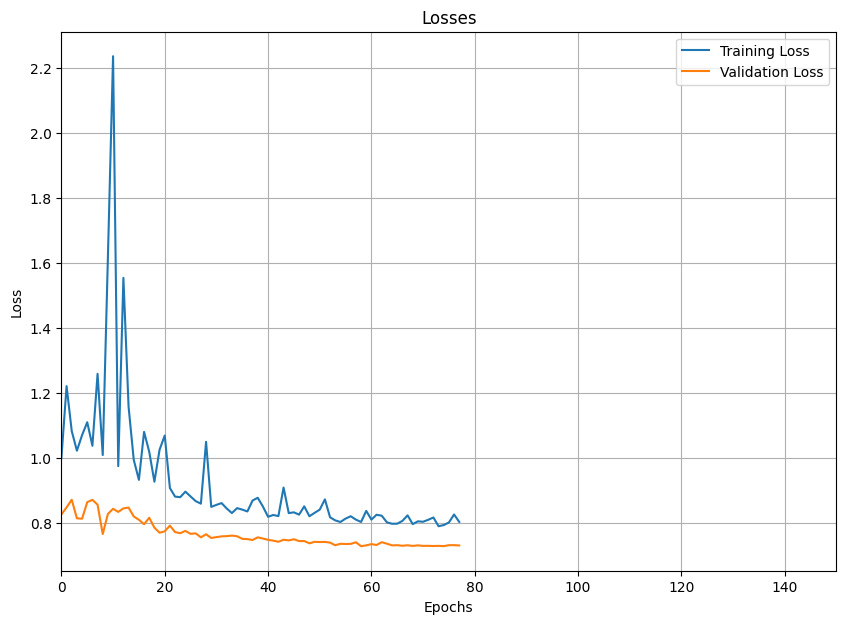

Early stopping at epoch 78 with validation loss: 0.7282
Test MSE: 0.7240
y_pred shape: (129, 80)
y_true shape: (129, 80)


In [ ]:
# ─── Prepare the data ─────────────────────────────────────────────────────
train_loader_left, val_loader_left, test_loader_left = prep_data(
    l_ar, a_ar,
    batch_size=32,
    shuffle=True
)

# ─── Inspect input dim ────────────────────────────────────────────────────
sample_x, _ = next(iter(train_loader_left))
n_neurons_in = sample_x.shape[2]
print('n_neurons:', n_neurons_in)

# ─── Instantiate your model ───────────────────────────────────────────────
# model_left = SpikingAttentionLSTM(
#     input_dim=n_neurons_in,
#     hidden_dim=64,
#     output_dim=80,   # predicting one spike‐count per trial
#     num_layers=2,
#     dropout= 0.5,
#     pool = 'mean'
# )

model_left = SimpleAvgMLP(
    input_dim=n_neurons_in,
    output_dim=80,   # predicting one spike‐count per trial
    hidden_dims=[256, 128, 96],
    dropout=0.5
)

# ─── Train ────────────────────────────────────────────────────────────────
criterion = nn.MSELoss()
loss_history_left, validation_loss_history_left = train(
    model_left,
    train_loader_left,
    val_loader_left,   # now passing the val_loader
    criterion,
    epochs=150,
    lr=1e-2,
    wd=1e-4,
    patience=20
)

# ─── Final evaluation on test set ────────────────────────────────────────
model_left.eval()
test_mse = 0.0
all_preds, all_trues = [], []
with torch.no_grad():
    for xb, yb in test_loader_left:
        preds = model_left(xb)
        test_mse += criterion(preds, yb).item()
        all_preds.append(preds.cpu().numpy())
        all_trues.append(yb.cpu().numpy())

test_mse /= len(test_loader_left)
print(f"Test MSE: {test_mse:.4f}")


# ─── (Optional) flatten predictions & truths into arrays ─────────────────
y_pred_trained_l = np.concatenate(all_preds, axis=0)  # shape (n_test, 1)
y_true_test_l   = np.concatenate(all_trues, axis=0)  # same shape
print('y_pred shape:', y_pred_trained_l.shape)
print('y_true shape:', y_true_test_l.shape)


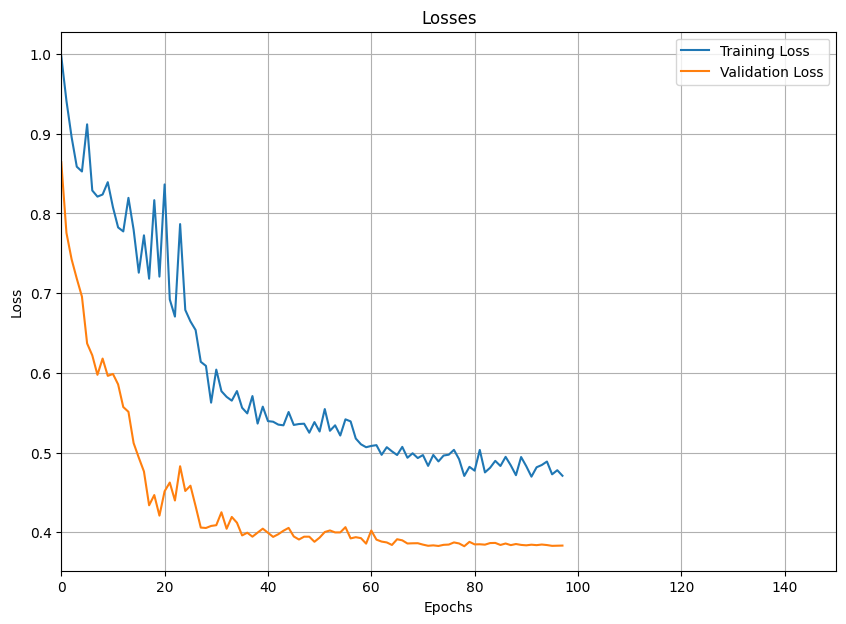

Early stopping at epoch 98 with validation loss: 0.3825
Right‐set Test MSE: 0.3355
y_pred_right shape: (129, 80)
y_true_right shape: (129, 80)


In [27]:
#preparing the right‐condition data 
train_loader_right, val_loader_right, test_loader_right = prep_data(
    r_ar, a_ar,
    batch_size=32,
    shuffle=True
)

#inspecting input dim for right model 
sample_x_r, _ = next(iter(train_loader_right))
n_neurons_in_r = sample_x_r.shape[2]
print('n_neurons (right):', n_neurons_in_r)

#instantiate the right‐model
# model_right = SpikingAttentionLSTM(
#     input_dim=n_neurons_in_r,
#     hidden_dim=64,
#     output_dim=80,   # predicting one spike‐count per trial
#     num_layers=2,
#     dropout= 0.5,
#     pool = 'mean'
# )

model_right = SimpleAvgMLP(
    input_dim=n_neurons_in,
    output_dim=80,   # predicting one spike‐count per trial
    hidden_dims=[128, 128, 96, 96, 80],
    dropout=0.5
)

# training 
criterion = nn.MSELoss()
loss_history_right, validation_loss_history_right = train(
    model_right,
    train_loader_right,
    val_loader_right,   # now passing the val_loader
    criterion,
    epochs=150,
    lr=1e-2,
    wd=1e-4,
    patience=20
)

#final evaluation on right test set
model_right.eval()
test_mse_right = 0.0
all_preds_r, all_trues_r = [], []

with torch.no_grad():
    for xb, yb in test_loader_right:
        preds_r = model_right(xb)
        test_mse_right += nn.MSELoss()(preds_r, yb).item()
        all_preds_r.append(preds_r.cpu().numpy())
        all_trues_r.append(yb.cpu().numpy())

test_mse_right /= len(test_loader_right)
print(f"Right‐set Test MSE: {test_mse_right:.4f}")

#flattening right predictions & truths
y_pred_trained_r = np.concatenate(all_preds_r, axis=0)  # shape (n_test, 1)
y_true_test_r    = np.concatenate(all_trues_r, axis=0)  # same shape
print('y_pred_right shape:', y_pred_trained_r.shape)
print('y_true_right shape:',  y_true_test_r.shape)



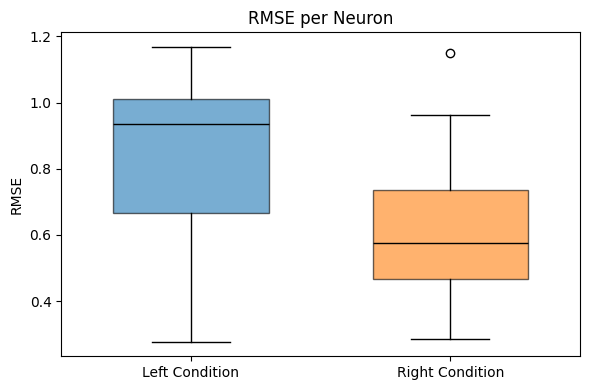

In [28]:
def per_neuron_rmse(y_true, y_pred):
    # y_true, y_pred are (n_neurons, n_points)
    return np.sqrt(np.mean((y_true - y_pred)**2, axis=0))

rmse_left  = per_neuron_rmse(y_true_test_l,  y_pred_trained_l)
rmse_right = per_neuron_rmse(y_true_test_r, y_pred_trained_r)

def plot_in_vs_out(in_vals, out_vals,
                   labels=('In','Out'),
                   ylabel='Pearson r',
                   title=None):
    fig, ax = plt.subplots(figsize=(6, 4))
    # tell boxplot to draw filled boxes (patch_artist=True)
    bp = ax.boxplot([in_vals, out_vals],
                    widths=0.6,
                    notch=False,
                    patch_artist=True)
    
    # color sequence: C0 is blue, C1 is orange in the default Matplotlib cycle
    colors = ['C0','C1']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # (optional) make whiskers/caps match box edge
    for element in ['whiskers','caps']:
        for line in bp[element]:
            line.set(color='k')
            
    
    for median in bp['medians']:
        median.set(color='k', linewidth=1)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_in_vs_out(rmse_left, rmse_right, 
                labels=('Left Condition', 'Right Condition'),
                ylabel='RMSE',
                title='RMSE per Neuron')   


In [29]:
from scipy.stats import ttest_rel, wilcoxon

diffs = rmse_left - rmse_right
t_stat, p_t = ttest_rel(rmse_left, rmse_right)
w_stat, p_w = wilcoxon(rmse_left, rmse_right)


mean_diff = np.mean(diffs)
sd_diff   = np.std(diffs, ddof=1)
cohens_d  = mean_diff / sd_diff

print(f"Paired t‑test:     t = {t_stat:.2f}, p = {p_t:.3f}")
print(f"Wilcoxon test:     W = {w_stat:.2f}, p = {p_w:.3f}")
print(f"Mean(left–right) = {mean_diff:.3f}, Cohen’s d = {cohens_d:.2f}")


Paired t‑test:     t = 10.78, p = 0.000
Wilcoxon test:     W = 55.00, p = 0.000
Mean(left–right) = 0.248, Cohen’s d = 1.21


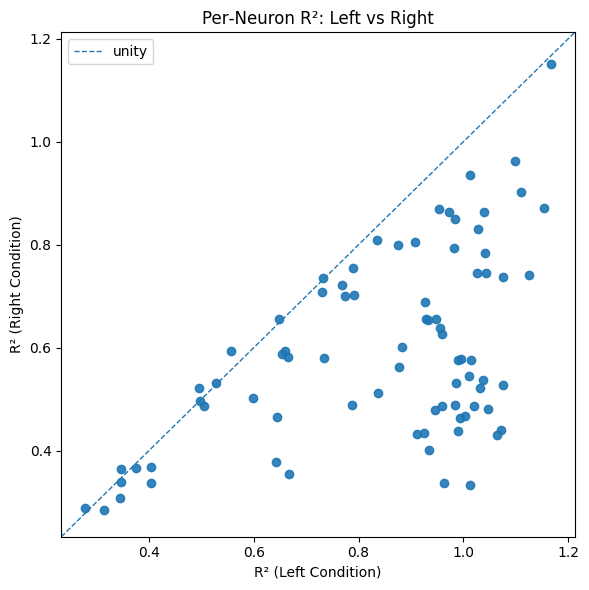

In [31]:
fig, ax = plt.subplots(figsize=(6,6))

# scatter of Left vs Right
ax.scatter(rmse_left, rmse_right, alpha=0.9)

# unity line: from the min to max of both axes
lims = [
    np.min([ax.get_xlim()[0], ax.get_ylim()[0]]),
    np.max([ax.get_xlim()[1], ax.get_ylim()[1]])
]
ax.plot(lims, lims, linestyle='--', linewidth=1, label='unity')

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel('R² (Left Condition)')
ax.set_ylabel('R² (Right Condition)')
ax.set_title('Per‑Neuron R²: Left vs Right')
ax.legend()
plt.tight_layout()
plt.show()